# Hotel Booking Demand

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("hotel_bookings.csv")

In [3]:
df.shape

(119390, 32)

In [4]:
print(df.columns)

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date'],
      dtype='str')


In [5]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [6]:
## Find out general information about the Dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal                       

In [7]:
## Find out statictics about the Dataset
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


In [8]:
## Check for missing values in all columns

df.isnull().sum()

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

In [9]:
## Check the shape of the Dataset

df.shape

(119390, 32)

In [10]:
## Fill missing values in the company column with 0

df['company'] = df['company'].fillna(0)

In [11]:
## Check for unique values in country column

df['country'].unique()

<StringArray>
['PRT', 'GBR', 'USA', 'ESP', 'IRL', 'FRA',   nan, 'ROU', 'NOR', 'OMN',
 ...
 'ATA', 'GTM', 'ASM', 'MRT', 'NCL', 'KIR', 'SDN', 'ATF', 'SLE', 'LAO']
Length: 178, dtype: str

In [12]:
## Fill missing values in the agent column with 0

df['agent'] = df['agent'].fillna(0)

In [13]:
## Fill missing values in the children column with the mode

df['children'] = df['children'].fillna(df['children'].mode()[0])

In [14]:
## Fill missing values in the country column with "OTH" for other

df['country'] = df['country'].fillna('OTH')

In [15]:
## Check if there are still any Missing Values

df.columns[df.isna().any()]

Index([], dtype='str')

In [16]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,0.0,0.0,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,0.0,0.0,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,0.0,0.0,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,0.0,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,0.0,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [17]:
## Drop Bookings with no people

df = df.drop(df[df['adults'] + df['children'] + df['babies'] == 0].index)

In [18]:
## Check for shape
df.shape

(119210, 32)

In [19]:
df['deposit_type'].unique()

<StringArray>
['No Deposit', 'Refundable', 'Non Refund']
Length: 3, dtype: str

In [20]:
df['reservation_status'].unique()

<StringArray>
['Check-Out', 'Canceled', 'No-Show']
Length: 3, dtype: str

In [21]:
## Drop reservation_status
df = df.drop(columns=['reservation_status'])

In [22]:
df.shape

(119210, 31)

In [23]:
## Map the months to chronological number

month_map = {
    'January': 1, 'February': 2, 'March': 3, 'April': 4, 
    'May': 5, 'June': 6, 'July': 7, 'August': 8, 
    'September': 9, 'October': 10, 'November': 11, 'December': 12
}
df['arrival_date_month_encoded'] = df['arrival_date_month'].map(month_map)

In [24]:
# Apply Sine and Cosine transformations

df['month_sin'] = np.sin(2 * np.pi * df['arrival_date_month_encoded'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['arrival_date_month_encoded'] / 12)

In [25]:
month_temp_map = {
    "January": 1, "February": 2, "March": 3, "April": 4, "May": 5, "June": 6,
    "July": 7, "August": 8, "September": 9, "October": 10, "November": 11, "December": 12
}

# Construct the full date string to find out the exact day of the week
df["_temp_month_num"] = df["arrival_date_month"].map(month_temp_map)
df["arrival_date_full"] = pd.to_datetime(
    df["arrival_date_year"].astype(str) + "-" +
    df["_temp_month_num"].astype(str) + "-" +
    df["arrival_date_day_of_month"].astype(str)
)

# Extract day of the week (4 = Friday, 5 = Saturday) for weekend check
df["is_weekend"] = df["arrival_date_full"].dt.dayofweek.isin([4, 5]).astype(int)

# Map months to high, medium, and low travel seasons
season_map = {
    "January": 0, "February": 0, "December": 0, "November": 0,  # Low season
    "March": 1, "April": 1, "May": 1, "June": 1, "September": 1, "October": 1, # Medium season
    "July": 2, "August": 2  # High season
}
df["seasonality_index"] = df["arrival_date_month"].map(season_map)

# Clean up the temporary generation columns 
df.drop(columns=["arrival_date_full", "_temp_month_num"], inplace=True)
df.drop(columns=['arrival_date_month', 'arrival_date_month_encoded'], inplace=True)





### BEHAVIORAL FEATURES (Safe to run directly)

# Total stay length calculation
df["total_stay"] = df["stays_in_weekend_nights"] + df["stays_in_week_nights"]

# Right-skewed lead time log transformation (log1p handles 0 flawlessly)
df["lead_time_log"] = np.log1p(df["lead_time"])

In [26]:
## Check the data types of all the columns
df.dtypes

hotel                                 str
is_canceled                         int64
lead_time                           int64
arrival_date_year                   int64
arrival_date_week_number            int64
arrival_date_day_of_month           int64
stays_in_weekend_nights             int64
stays_in_week_nights                int64
adults                              int64
children                          float64
babies                              int64
meal                                  str
country                               str
market_segment                        str
distribution_channel                  str
is_repeated_guest                   int64
previous_cancellations              int64
previous_bookings_not_canceled      int64
reserved_room_type                    str
assigned_room_type                    str
booking_changes                     int64
deposit_type                          str
agent                             float64
company                           

In [27]:
# Drop the columns that cause data noise or leakage
columns_to_drop = ['arrival_date_year', 'lead_time', 'assigned_room_type']
df_cleaned = df.drop(columns=columns_to_drop)


In [28]:
#  Identify the text columns for One-Hot Encoding
categorical_cols = ['hotel', 'meal', 'market_segment', 'distribution_channel', 'reserved_room_type', 'customer_type']

In [29]:
#  Apply One-Hot Encoding (drop_first=True prevents the dummy variable trap)
df_final = pd.get_dummies(df_cleaned, columns=categorical_cols, drop_first=True)

In [30]:
#  Quick check to make sure everything is numeric
print(df_final.dtypes)

is_canceled                         int64
arrival_date_week_number            int64
arrival_date_day_of_month           int64
stays_in_weekend_nights             int64
stays_in_week_nights                int64
adults                              int64
children                          float64
babies                              int64
country                               str
is_repeated_guest                   int64
previous_cancellations              int64
previous_bookings_not_canceled      int64
booking_changes                     int64
deposit_type                          str
agent                             float64
company                           float64
days_in_waiting_list                int64
adr                               float64
required_car_parking_spaces         int64
total_of_special_requests           int64
reservation_status_date               str
month_sin                         float64
month_cos                         float64
is_weekend                        

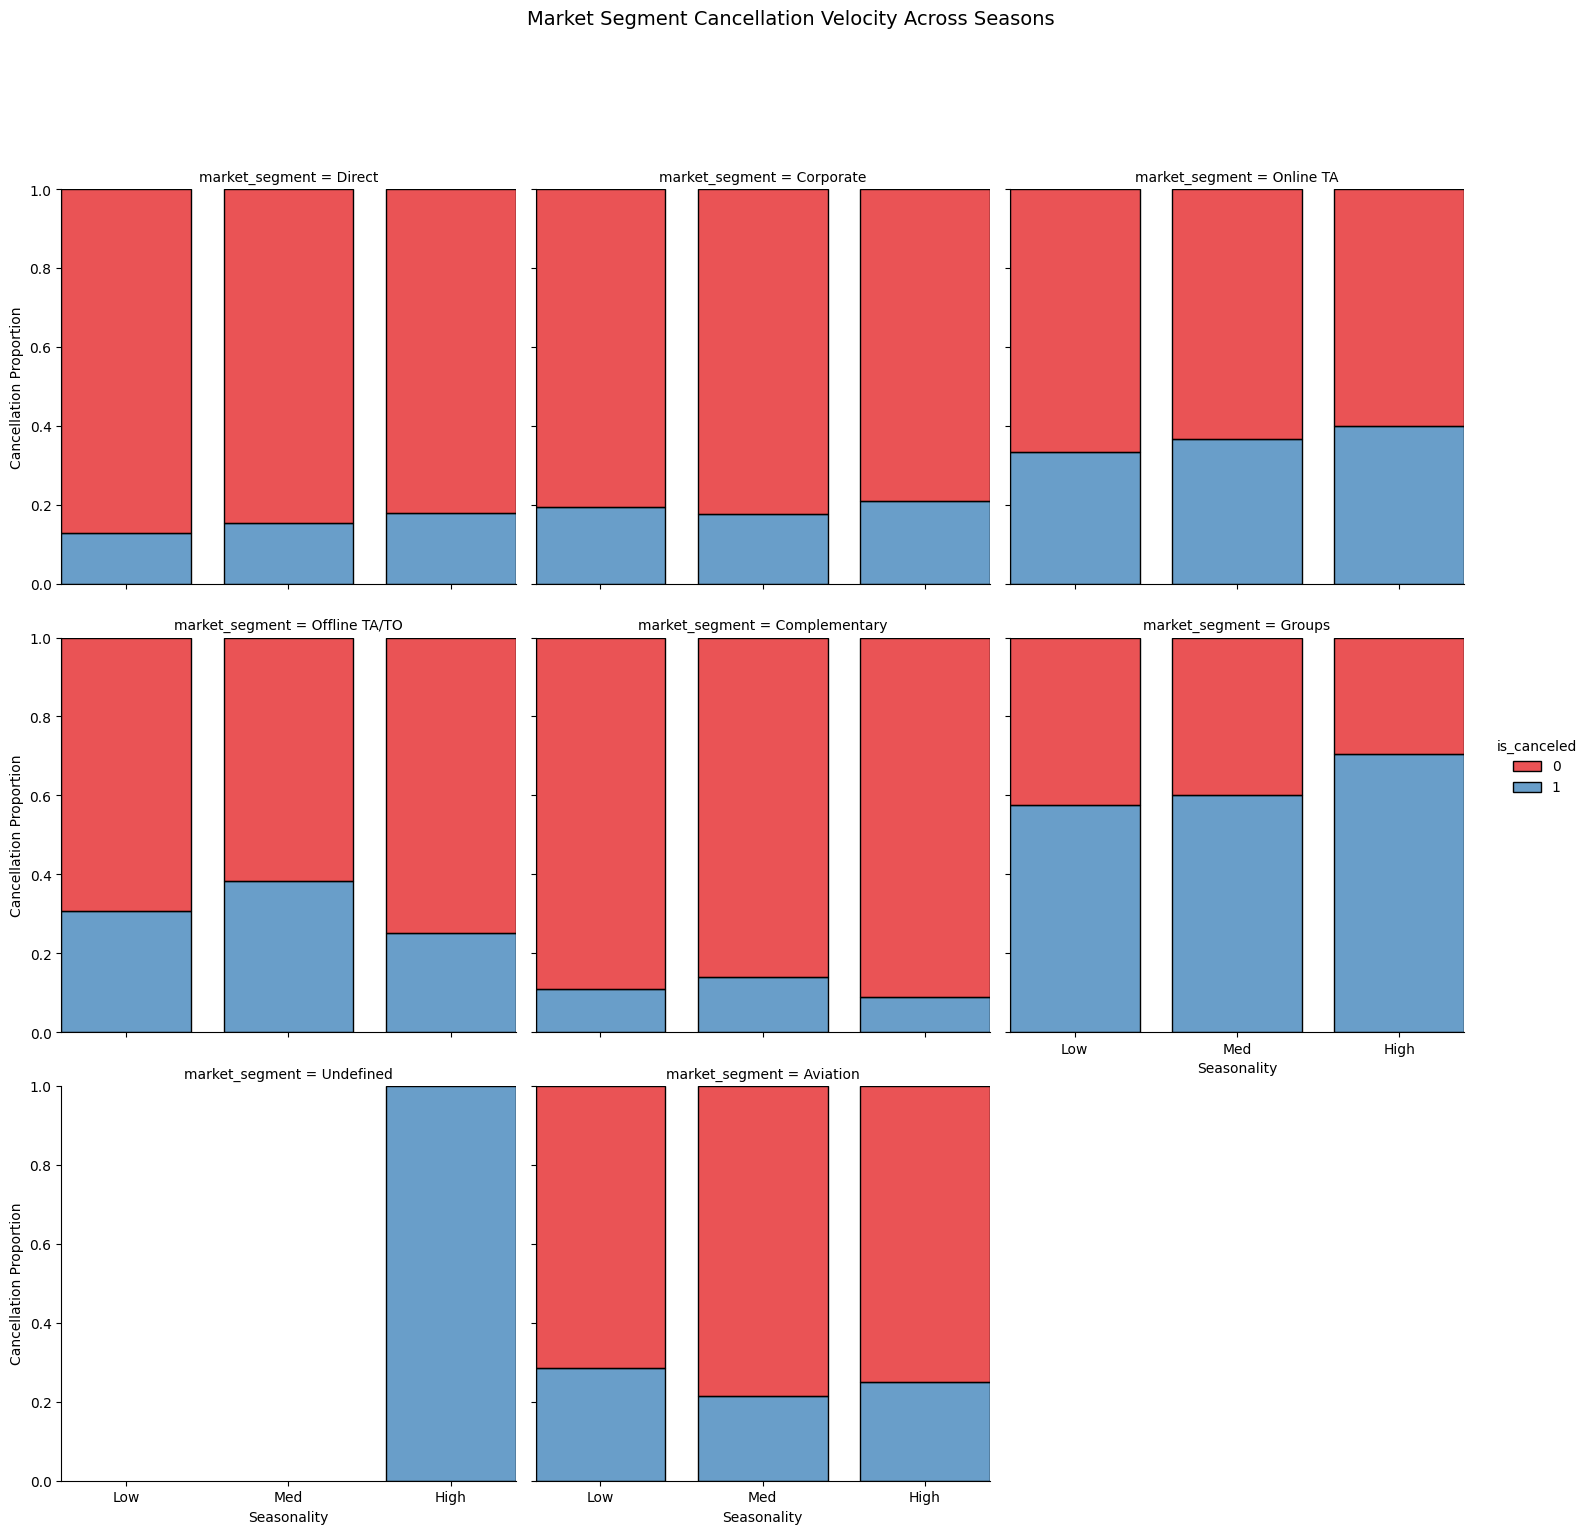

In [31]:
# Using sns.displot avoids the FacetGrid .index mapping bug entirely

g = sns.displot(
    data=df, 
    x="seasonality_index", 
    col="market_segment", 
    hue="is_canceled", 
    kind="hist",
    stat="probability", 
    multiple="fill", 
    discrete=True,       
    shrink=0.8,         
    palette="Set1",
    col_wrap=3
)

# Clean up axes ticks to explicitly show names instead of floating decimals
g.set(xticks=[0, 1, 2], xticklabels=['Low', 'Med', 'High'])

g.set_axis_labels("Seasonality", "Cancellation Proportion")
g.fig.subplots_adjust(top=0.9)
g.fig.suptitle("Market Segment Cancellation Velocity Across Seasons", fontsize=14, y=1.02)

plt.show()

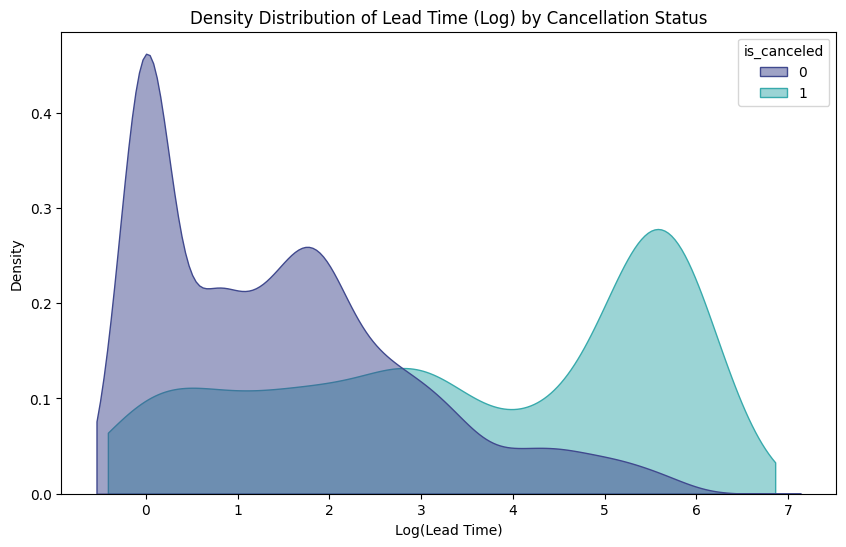

In [32]:
## Density Distribution of Lead Time (Log) by Cancellation Status
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x="lead_time_log", hue="is_canceled", weights="is_repeated_guest", fill=True, common_norm=False, palette="mako", alpha=0.5)
plt.title("Density Distribution of Lead Time (Log) by Cancellation Status")
plt.xlabel("Log(Lead Time)")
plt.ylabel("Density")
plt.show()

In [33]:
import xgboost as xgb
import re
from sklearn.model_selection import train_test_split

# Map deposit_type from text to logical integers
deposit_mapping = {"No Deposit": 0, "Refundable": 1, "Non Refundable": 2}
df_final["deposit_type"] = df_final["deposit_type"].map(deposit_mapping)

# Drop data leakage and targets to prepare our features
X = df_final.drop(
    columns=["is_canceled", "adr", "reservation_status_date", "country"],
    errors="ignore",
)
y = df_final["is_canceled"]

# split into Train and Test matrices
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [34]:
# Convert boolean flags (True/False) to numeric bits (1/0)
bool_cols = X_train.select_dtypes(include="bool").columns
X_train = X_train.astype({col: "int" for col in bool_cols})
X_test = X_test.astype({col: "int" for col in bool_cols})

In [35]:
# Scrub column text formatting to remove spaces and brackets
regex = re.compile(r"\[|\]|<|#|\s|,")
X_train.columns = [regex.sub("_", col) for col in X_train.columns]
X_test.columns = [regex.sub("_", col) for col in X_test.columns]

In [36]:
#  Initialize the XGBoost Classifier
model = xgb.XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

In [37]:
model.fit(X_train, y_train)

/Users/newowner/Desktop/DS_project/myenv_dsp/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [20:15:03] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [38]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

print("=== Confusion Matrix ===")
print(confusion_matrix(y_test, y_pred))

print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred))

print("\n=== ROC-AUC Score ===")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba):.4f}")

=== Confusion Matrix ===
[[14059   943]
 [ 3074  5766]]

=== Classification Report ===
              precision    recall  f1-score   support

           0       0.82      0.94      0.87     15002
           1       0.86      0.65      0.74      8840

    accuracy                           0.83     23842
   macro avg       0.84      0.79      0.81     23842
weighted avg       0.83      0.83      0.83     23842


=== ROC-AUC Score ===
ROC-AUC: 0.9007


In [39]:
from sklearn.model_selection import RandomizedSearchCV
import xgboost as xgb

# 1. Initialize the base classifier
xgb_model = xgb.XGBClassifier(eval_metric='logloss', random_state=42)

# 2. Define the parameter distribution space to search through
param_dist = {
    'n_estimators': [100, 150, 200],
    'max_depth': [5, 7, 9],
    'learning_rate': [0.05, 0.1, 0.2],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'scale_pos_weight': [1, 1.5, 2] # Forces model to prioritize catching cancellations
}

# 3. Setup the Randomized Search with 3-fold Cross-Validation
# n_iter=10 means it will randomly try 10 different combinations
random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_dist,
    n_iter=10,
    scoring='roc_auc',
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

# 4. Run the optimization search
random_search.fit(X_train, y_train)

print(f"Best Hyperparameters Found: {random_search.best_params_}")

Fitting 3 folds for each of 10 candidates, totalling 30 fits
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=9, n_estimators=100, scale_pos_weight=1.5, subsample=0.9; total time=  21.6s
[CV] END colsample_bytree=0.8, learning_rate=0.2, max_depth=9, n_estimators=150, scale_pos_weight=1, subsample=0.7; total time=  30.2s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=9, n_estimators=100, scale_pos_weight=1.5, subsample=0.9; total time=  21.8s
[CV] END colsample_bytree=0.8, learning_rate=0.2, max_depth=9, n_estimators=150, scale_pos_weight=1, subsample=0.7; total time=  30.5s
[CV] END colsample_bytree=0.8, learning_rate=0.2, max_depth=9, n_estimators=150, scale_pos_weight=1, subsample=0.7; total time=  29.7s
[CV] END colsample_bytree=0.7, learning_rate=0.1, max_depth=9, n_estimators=150, scale_pos_weight=1.5, subsample=0.8; total time=  27.8s
[CV] END colsample_bytree=0.7, learning_rate=0.1, max_depth=9, n_estimators=150, scale_pos_weight=1.5, subsample=0.8; tot

In [40]:
# Extract the optimized model
best_model = random_search.best_estimator_

# Generate new predictions
y_pred_opt = best_model.predict(X_test)
y_pred_proba_opt = best_model.predict_proba(X_test)[:, 1]

# Print the new optimized scores
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
print("\n=== Optimized Confusion Matrix ===")
print(confusion_matrix(y_test, y_pred_opt))

print("\n=== Optimized Classification Report ===")
print(classification_report(y_test, y_pred_opt))

print("\n=== Optimized ROC-AUC Score ===")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba_opt):.4f}")


=== Optimized Confusion Matrix ===
[[13822  1180]
 [ 2296  6544]]

=== Optimized Classification Report ===
              precision    recall  f1-score   support

           0       0.86      0.92      0.89     15002
           1       0.85      0.74      0.79      8840

    accuracy                           0.85     23842
   macro avg       0.85      0.83      0.84     23842
weighted avg       0.85      0.85      0.85     23842


=== Optimized ROC-AUC Score ===
ROC-AUC: 0.9232


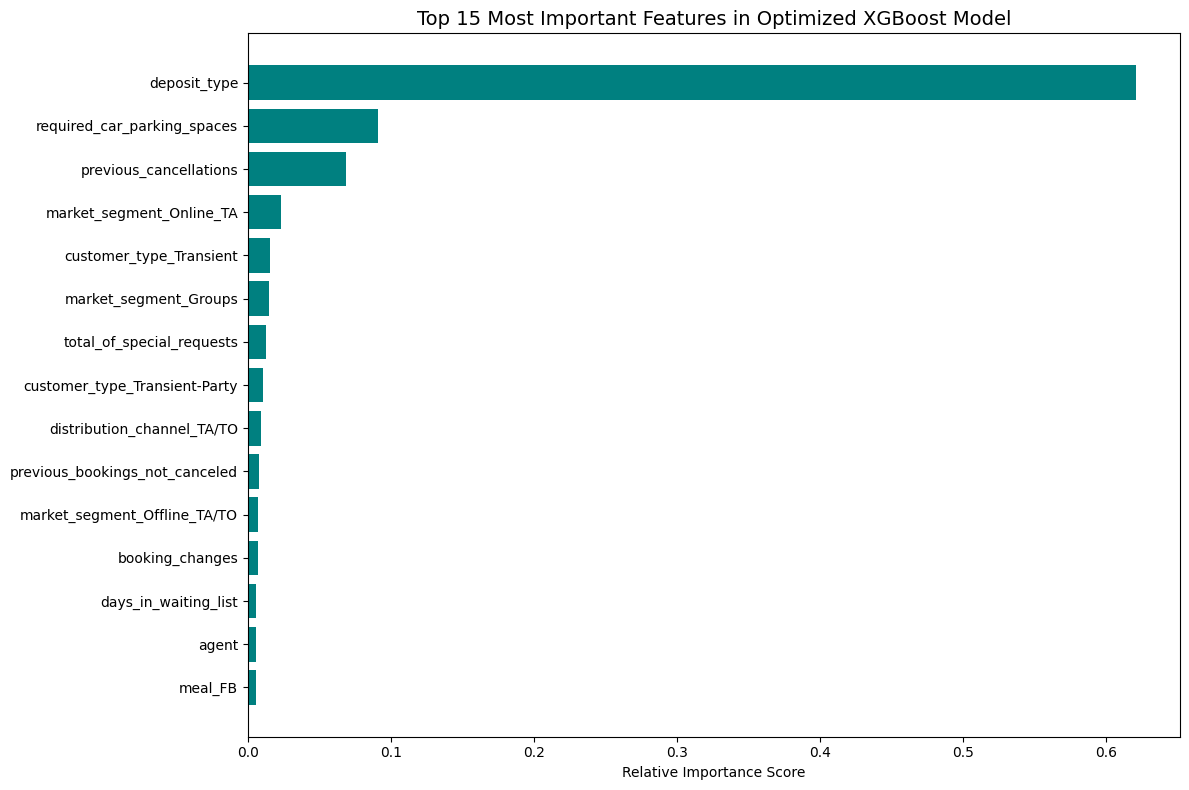

In [41]:
# Extract feature importances from your best model
importances = best_model.feature_importances_
indices = np.argsort(importances)[::-1]

# Take the top 15 most impactful features for visual clarity
top_n = 15
plt.figure(figsize=(12, 8))
plt.title("Top 15 Most Important Features in Optimized XGBoost Model", fontsize=14)
plt.barh(range(top_n), importances[indices[:top_n]][::-1], color='teal', align="center")
plt.yticks(range(top_n), [X_train.columns[i] for i in indices[:top_n]][::-1])
plt.xlabel("Relative Importance Score")
plt.tight_layout()
plt.show()

In [ ]:
import plotly.express as px
import pandas as pd

# Group the data by country and calculate total cancellations and cancellation rates
country_data = df.groupby('country').agg(
    total_cancellations=('is_canceled', 'sum'),
    total_bookings=('is_canceled', 'count')
).reset_index()

# Calculate the percentage of bookings canceled per country to keep the map fair
country_data['cancellation_rate (%)'] = round((country_data['total_cancellations'] / country_data['total_bookings']) * 100, 2)

# Filter out countries with very few bookings to eliminate extreme statistical noise
country_data = country_data[country_data['total_bookings'] > 10]

# Build the interactive world map using Plotly
fig = px.choropleth(
    country_data,
    locations="country",            
    locationmode="ISO-3",           
    color="total_cancellations",    
    hover_name="country",          
    hover_data=["cancellation_rate (%)", "total_bookings"], 
    color_continuous_scale=px.colors.sequential.OrRd,
    title="Global Distribution of Hotel Booking Cancellations"
)

# Adjust margins for a clean presentation layout
fig.update_layout(margin={"r":0,"t":40,"l":0,"b":0})

fig.show()